In [1]:
# Import Library
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from config import IMAGE_SIZE

In [4]:
# Load the model 
model = load_model("../models/best_model.keras")

model.summary()

Model: "CropDiseaseEfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,075,671 (23.18 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 1,350,734 (5.15 MB)

In [5]:
# Select an Image
from pathlib import Path
import random

dataset = Path("../data/raw/color")

images = []

for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.JPEG", "*.png"):
    images.extend(dataset.rglob(ext))

image_path = random.choice(images)

print(image_path)

..\data\raw\color\Corn_(maize)___Common_rust_\RS_Rust 2475.JPG


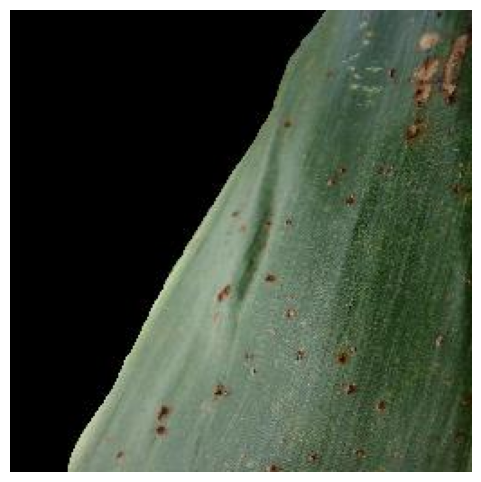

In [6]:
# Display an Image
image = tf.keras.utils.load_img(image_path)

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.axis("off")

plt.show()

In [7]:
# Preprocess the Image
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMAGE_SIZE,
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0,
)

In [8]:
model.summary()

Model: "CropDiseaseEfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,075,671 (23.18 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 1,350,734 (5.15 MB)

In [9]:
from src.explainability.gradcam import (
    make_gradcam_heatmap,
    overlay_heatmap,
)

In [10]:
# Generate A HeatMap
heatmap = make_gradcam_heatmap(
    img_array,
    model,
)

plt.figure(figsize=(6,6))

plt.imshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.show()

ValueError: Output with path `0` is not connected to `inputs`

In [11]:
base_model = model.get_layer("efficientnetb0")

print("Last 10 layers:")

for layer in base_model.layers[-10:]:
    print(layer.name, "-", layer.__class__.__name__)

Last 10 layers:
block7a_se_squeeze - GlobalAveragePooling2D
block7a_se_reshape - Reshape
block7a_se_reduce - Conv2D
block7a_se_expand - Conv2D
block7a_se_excite - Multiply
block7a_project_conv - Conv2D
block7a_project_bn - BatchNormalization
top_conv - Conv2D
top_bn - BatchNormalization
top_activation - Activation


In [12]:
from src.inference.disease_info import DISEASE_INFO

print(DISEASE_INFO["Apple___Apple_scab"])

{'description': 'Apple scab is a fungal disease that causes dark lesions on leaves and fruits.', 'treatment': ['Remove infected leaves.', 'Apply recommended fungicides.', 'Improve air circulation around trees.']}
